In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mapping to/from integers
# 构建词汇表 -> 索引
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [56]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one? 
X, Y = [], []  # X是神经网络的输入， Y是标签
for w in words:
  
  #print(w)
  context = [0] * block_size  # 初始化上下文窗口，[0,0,0]
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append 裁掉第一位
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [57]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [119]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])      # 训练集
Xdev, Ydev = build_dataset(words[n1:n2])  # 验证集
Xte, Yte = build_dataset(words[n2:])      # 测试集


torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [118]:
print(len(words))
print(n1)  # 训练集
print(n2)  # 验证集

32033
25626
28829


In [7]:
C = torch.randn((27, 2))

In [8]:
C[5]

tensor([-0.5191, -1.3842])

In [9]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.5191, -1.3842])

In [10]:
C[X].shape

torch.Size([32, 3, 2])

In [11]:
X[13,2]

tensor(1)

In [12]:
C[X][13,2]

tensor([1.1070, 0.5973])

In [13]:
C[1]

tensor([1.1070, 0.5973])

In [14]:
emb = C[X]
emb.shape   # [样本数量, 上下文长度, 特征维度]

torch.Size([32, 3, 2])

In [15]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [16]:
emb @ W1 + b1 

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [25]:
h = emb.view(32, 6) @ W1 + b1   # 第一个编码可以为负一， pytorch可以根据第二个括号的值自动适配第一个

In [24]:
h.shape

torch.Size([32, 100])

In [17]:
torch.cat([emb[:, 0, :], emb[: , 1, :], emb[: , 2, :]], 1).shape # 合并1维度和2维度

torch.Size([32, 6])

In [18]:
torch.cat(torch.unbind(emb, 1), 1).shape # 与上行等价，且更加简洁、方便

torch.Size([32, 6])

In [19]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [20]:
a.shape

torch.Size([18])

In [21]:
a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [26]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [27]:
h

tensor([[-0.9538, -0.2663,  0.0326,  ...,  0.9313,  0.9758, -0.9965],
        [-0.9961,  0.8173, -0.9843,  ...,  0.8216,  0.9891, -0.9994],
        [-0.3245,  0.8268, -0.9991,  ..., -0.7897,  0.9996, -0.9995],
        ...,
        [ 1.0000,  0.6776, -0.9977,  ...,  0.7821,  0.9397,  0.3926],
        [-0.9929, -0.9872,  0.9988,  ..., -0.0443, -0.3380,  0.0746],
        [ 0.7690,  0.7369, -0.7119,  ..., -0.9698,  0.8855, -0.9994]])

In [28]:
h.shape

torch.Size([32, 100])

In [29]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [30]:
logits = h @ W2 + b2

In [31]:
logits.shape

torch.Size([32, 27])

In [32]:
counts = logits.exp()

In [33]:
prob = counts / counts.sum(1, keepdims=True)

In [34]:
prob.shape

torch.Size([32, 27])

In [35]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [36]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.7021)

In [ ]:
# ------------ now made respectable :) ---------------

In [58]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [120]:
Xtr.shape, Ytr.shape # dataset


(torch.Size([182580, 3]), torch.Size([182580]))

In [151]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [152]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [153]:
for p in parameters:
    p.requires_grad = True

In [154]:
# 选取lrs为 1 到 0.001
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []
stepi = []

In [157]:

for i in range(50000):
    #minibatch 
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
#    print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

     # track stats
   # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())

3.1284852027893066


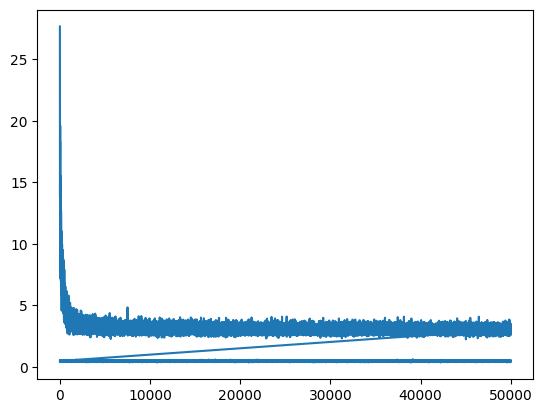

In [158]:
plt.plot(stepi, lossi)

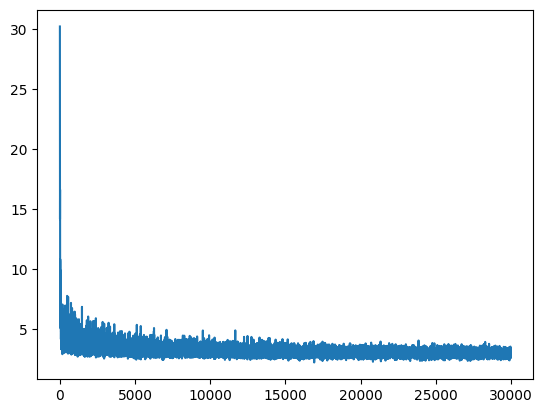

In [138]:
plt.plot(stepi, lossi)

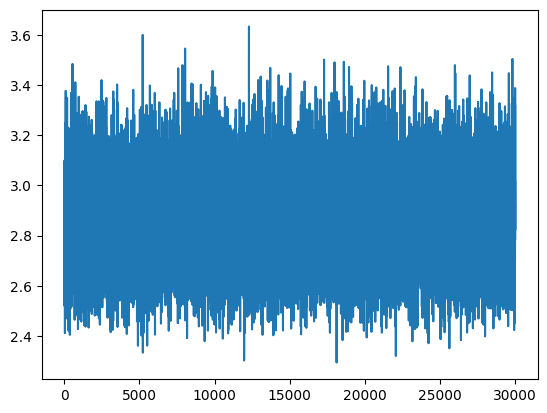

In [144]:
plt.plot(stepi, lossi)

In [160]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(3.0285, grad_fn=<NllLossBackward0>)

In [161]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(3.0257, grad_fn=<NllLossBackward0>)

In [ ]:
# 训练数据集    验证数据集    测试数据集
#    80%          10%          10%

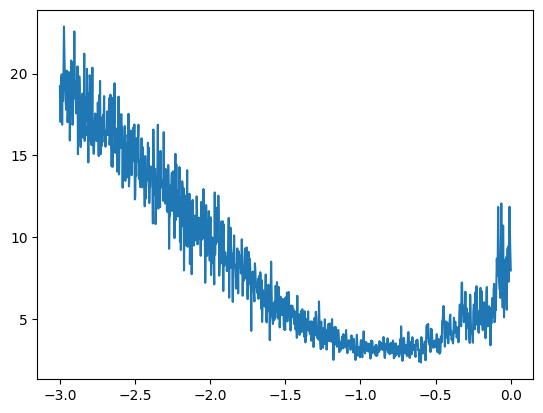

In [108]:
plt.plot(lri, lossi) # 选取山谷的学习率为最好的

In [70]:
torch.randint(0, X.shape[0], (32,))

tensor([137137, 191930,  68135, 169130, 183558,  53065,  30064,  96262, 180441,
        224819, 175360,  67801, 105443, 104808,  81733, 169605, 181084, 216756,
         54240,  58667,  66276,  47086, 166515, 129175, 217909, 108705, 188458,
        105244, 211009, 184215, 113383, 186263])

In [50]:
# 在一个很大负值的请路况下还有一个很大正值会报错，可以在logits最后面 - 去一个很大负值，不影响结果
logits = torch.tensor([-100, -3, 0, 5])
counts = logits.exp()
probs = counts / counts.sum()
probs


tensor([0.0000e+00, 3.3311e-04, 6.6906e-03, 9.9298e-01])

In [795]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

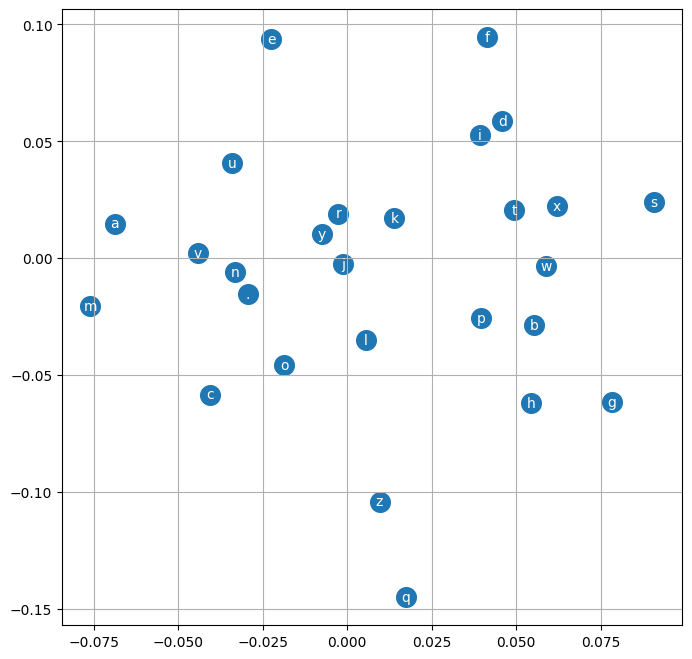

In [148]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [805]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [820]:


# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahela.
jhovi.
kimrin.
thil.
halanna.
jazhien.
amerynci.
aqui.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinton.
lilea.
jamilio.
jeron.
jaryni.
jace.
chrudeley.
